# **Goal** :
This notebook aims at producing TOD in a very simplified manner : project the QUBIC beam on the sky, take the value of the pixel, and add it to the TOD. 
This simplified TOD production will be used to test the convergence issue of the TOD with Nsub, and in particular to test our hypothesis about the pixellisation effect.

# Importation

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from tqdm import tqdm

from qubic.lib.Qdictionary import qubicDict
from qubic.lib.Instrument.Qacquisition import QubicMultiAcquisitions, compute_freq
from qubic.lib.Instrument.Qinstrument import QubicInstrument
from qubic.lib.Qsamplings import get_pointing, equ2gal
from qubic.lib.Qscene import QubicScene
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from qubic.lib.Qbeams import BeamGaussian, BeamFitted, MultiFreqBeam

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

%matplotlib inline

In [33]:
nside = 256
nreal = 1
convolve_beam = False

# Initialize QUBIC instance

Build the QUBIC dictionary, mandatory to use the QUBIC functions

In [34]:
# Build MPI communicator and qubic dict
dictfilename = 'qubic/qubic/dicts/pipeline_demo.dict'
d = qubicDict()
d.read_from_file(dictfilename)

center = equ2gal(d['RA_center'], d['DEC_center'])

d['nf_recon'] = 2
d['MultiBand'] = True
d['nside'] = nside

d['npointings'] = 1
d['synthbeam_kmax'] = 1
d['synthbeam_fraction'] = 1

d['noiseless'] = True
d['photon_noise'] = False
d['use_synthbeam_fits_file'] = False

In [35]:
# Build scanning strategy
sampling = get_pointing(d)

# Build scene
scene = QubicScene(d)

-------------- Random pointing ------------------


In [36]:
# Number of sub-acquisitions
nsub_max = 2000
nsub_list = np.arange(4, nsub_max + 1, 20)

In [37]:
# Build acquisition operator
Qacq = QubicMultiAcquisitions(d, 4, 2, sampling=sampling)

# Use Qacq to save the userful parameters
detectors_position =  Qacq.multiinstrument[0].detector.center

# Build the synthesised beam resolution
fwhm_synthbeam150 = Qacq.multiinstrument[0].synthbeam.peak150.fwhm

# Primary beam is frequency-dependent (its fwhm is baked in at construction,
# unlike synthbeam.peak150 which is a fixed 150 GHz reference), so we rebuild
# it per sub-band frequency below instead of reusing a single fixed instance.
beam_shape = d['beam_shape']
calibration = Qacq.multiinstrument[0].calibration

Info arch-laptop: Allocating (992,9) elements = 139.5 KiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (992,9) elements = 139.5 KiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (992,9) elements = 139.5 KiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (992,9) elements = 139.5 KiB in FSRRotation3dMatrix.__init__.


# Compute peaks position on the sky & Build TOD from them

In [38]:
nreal_tod_w_interp = []
nreal_tod_wo_interp = []
nreal_tod_w_interp_real = []
nreal_tod_wo_interp_real = []

for ireal in range(nreal):
    peaks_index_list = []
    tod_list_wo_interp = []
    tod_list_w_interp = []
    tod_list_wo_interp_real = []
    tod_list_w_interp_real = []
    freq_list = []
    fwhm_list = []
    bandwidth_list = []

    # Build CMB map
    cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
    cmb_map = hp.synfast(cl_cmb, nside, new=True, verbose=False).T# * 0 + 1

    for nsub in tqdm(nsub_list):
        peaks_index = []
        tod_w, tod_wo = [], []
        tod_w_real, tod_wo_real = [], []
        
        _, _, filter_nus150, deltas150, _, _ = compute_freq(
                150, int(nsub / 2), relative_bandwidth=d["filter_relative_bandwidth"], frequency_spacing="log")
        _, _, filter_nus220, deltas220, _, _ = compute_freq(
                220, int(nsub / 2), relative_bandwidth=d["filter_relative_bandwidth"], frequency_spacing="log")
        
        nus = np.concatenate((filter_nus150, filter_nus220)) * 1e9
        bandwidth = np.concatenate((deltas150, deltas220)) * 1e9
        fwhm = fwhm_synthbeam150 * 150e9 / nus
        for isub in range(nsub):

            # Rebuild the primary beam at this sub-band's actual frequency
            # (its width is baked in at construction, not re-evaluated per call)
            nu_ghz = nus[isub] / 1e9
            if beam_shape == 'gaussian':
                primary_beam = BeamGaussian(np.radians(calibration.get('primbeam')), nu=nu_ghz)
            elif beam_shape == 'fitted_beam':
                par, omega = calibration.get('primbeam')
                primary_beam = BeamFitted(par, omega, nu=nu_ghz)
            else:
                parth, parfr, parbeam, alpha, xspl = calibration.get('primbeam')
                primary_beam = MultiFreqBeam(parth, parfr, parbeam, alpha, xspl, nu=nu_ghz)

            theta, phi, val = QubicInstrument._peak_angles(
                scene,
                nus[isub],
                detectors_position,
                Qacq.multiinstrument[0].synthbeam,
                Qacq.multiinstrument[0].horn,
                primary_beam,
            )
            # print('Frequency: ', nus[isub], 'Theta: ', theta, 'Phi: ', phi)

            peaks_index.append(hp.ang2pix(nside, theta, phi))
            if convolve_beam:
                ConvOp = HealpixConvolutionGaussianOperator(fwhm[isub])
                conv_map = ConvOp(cmb_map)
            else:
                conv_map = cmb_map

            value_interp = hp.get_interp_val((conv_map[..., 0]), theta, phi)#, nest=True)
            value = conv_map[hp.ang2pix(nside, theta, phi)][..., 0]

            # Pixels sum for each sub-acquisition (no peak value / bandwidth weighting)
            tod_w.append(np.sum(value_interp, axis=-1))
            tod_wo.append(np.sum(value, axis=-1))

            # Real TOD, weighted by the synthesised beam peak value and the sub-band bandwidth
            tod_w_real.append(np.sum(value_interp * val, axis=-1) * bandwidth[isub])
            tod_wo_real.append(np.sum(value * val, axis=-1) * bandwidth[isub])
            
        peaks_index_list.append(np.array(peaks_index))
        tod_list_w_interp.append(np.array(tod_w))
        tod_list_wo_interp.append(np.array(tod_wo))
        tod_list_w_interp_real.append(np.array(tod_w_real))
        tod_list_wo_interp_real.append(np.array(tod_wo_real))
        freq_list.append(nus/1e9)
        fwhm_list.append(fwhm)
        bandwidth_list.append(bandwidth)
        
    nreal_tod_w_interp.append(tod_list_w_interp)
    nreal_tod_wo_interp.append(tod_list_wo_interp)
    nreal_tod_w_interp_real.append(tod_list_w_interp_real)
    nreal_tod_wo_interp_real.append(tod_list_wo_interp_real)
    
print("Shape nreal tod list : (Nreal), (len(nsub_list)), (nsub, npix)")

100%|██████████| 100/100 [07:35<00:00,  4.56s/it]

Shape nreal tod list : (Nreal), (len(nsub_list)), (nsub, npix)


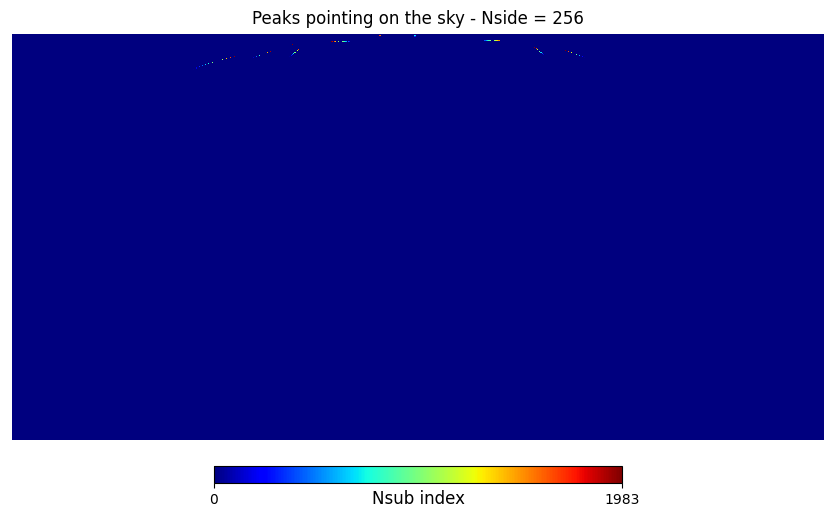

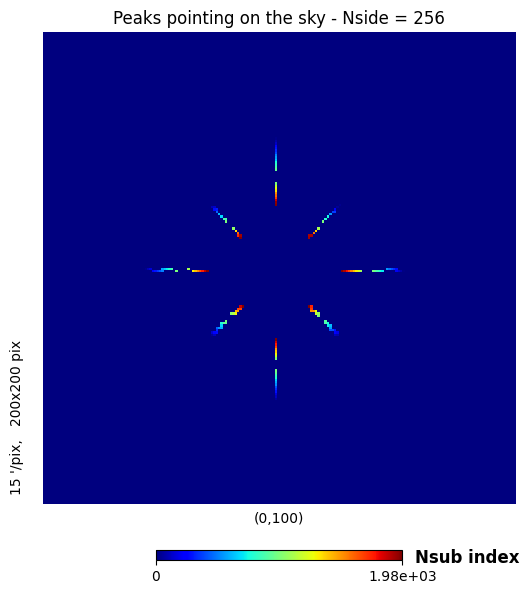

In [39]:
# Plot the projection of the peaks on the sky
test = np.zeros(hp.nside2npix(nside))

for i in range(np.shape(peaks_index_list[-1])[0]):
    test[peaks_index_list[-1][i, 0]] = i

colors = plt.cm.jet(np.linspace(0, 1, nsub))
hp.mollview(test, title=f"Peaks pointing on the sky - Nside = {nside}", cmap=plt.cm.colors.ListedColormap(colors), unit="Nsub index")
hp.gnomview(test, reso=15, rot=[0, 100], title=f"Peaks pointing on the sky - Nside = {nside}", cmap=plt.cm.colors.ListedColormap(colors), unit="Nsub index")

# Plot TOD

(131.25, 245.0)

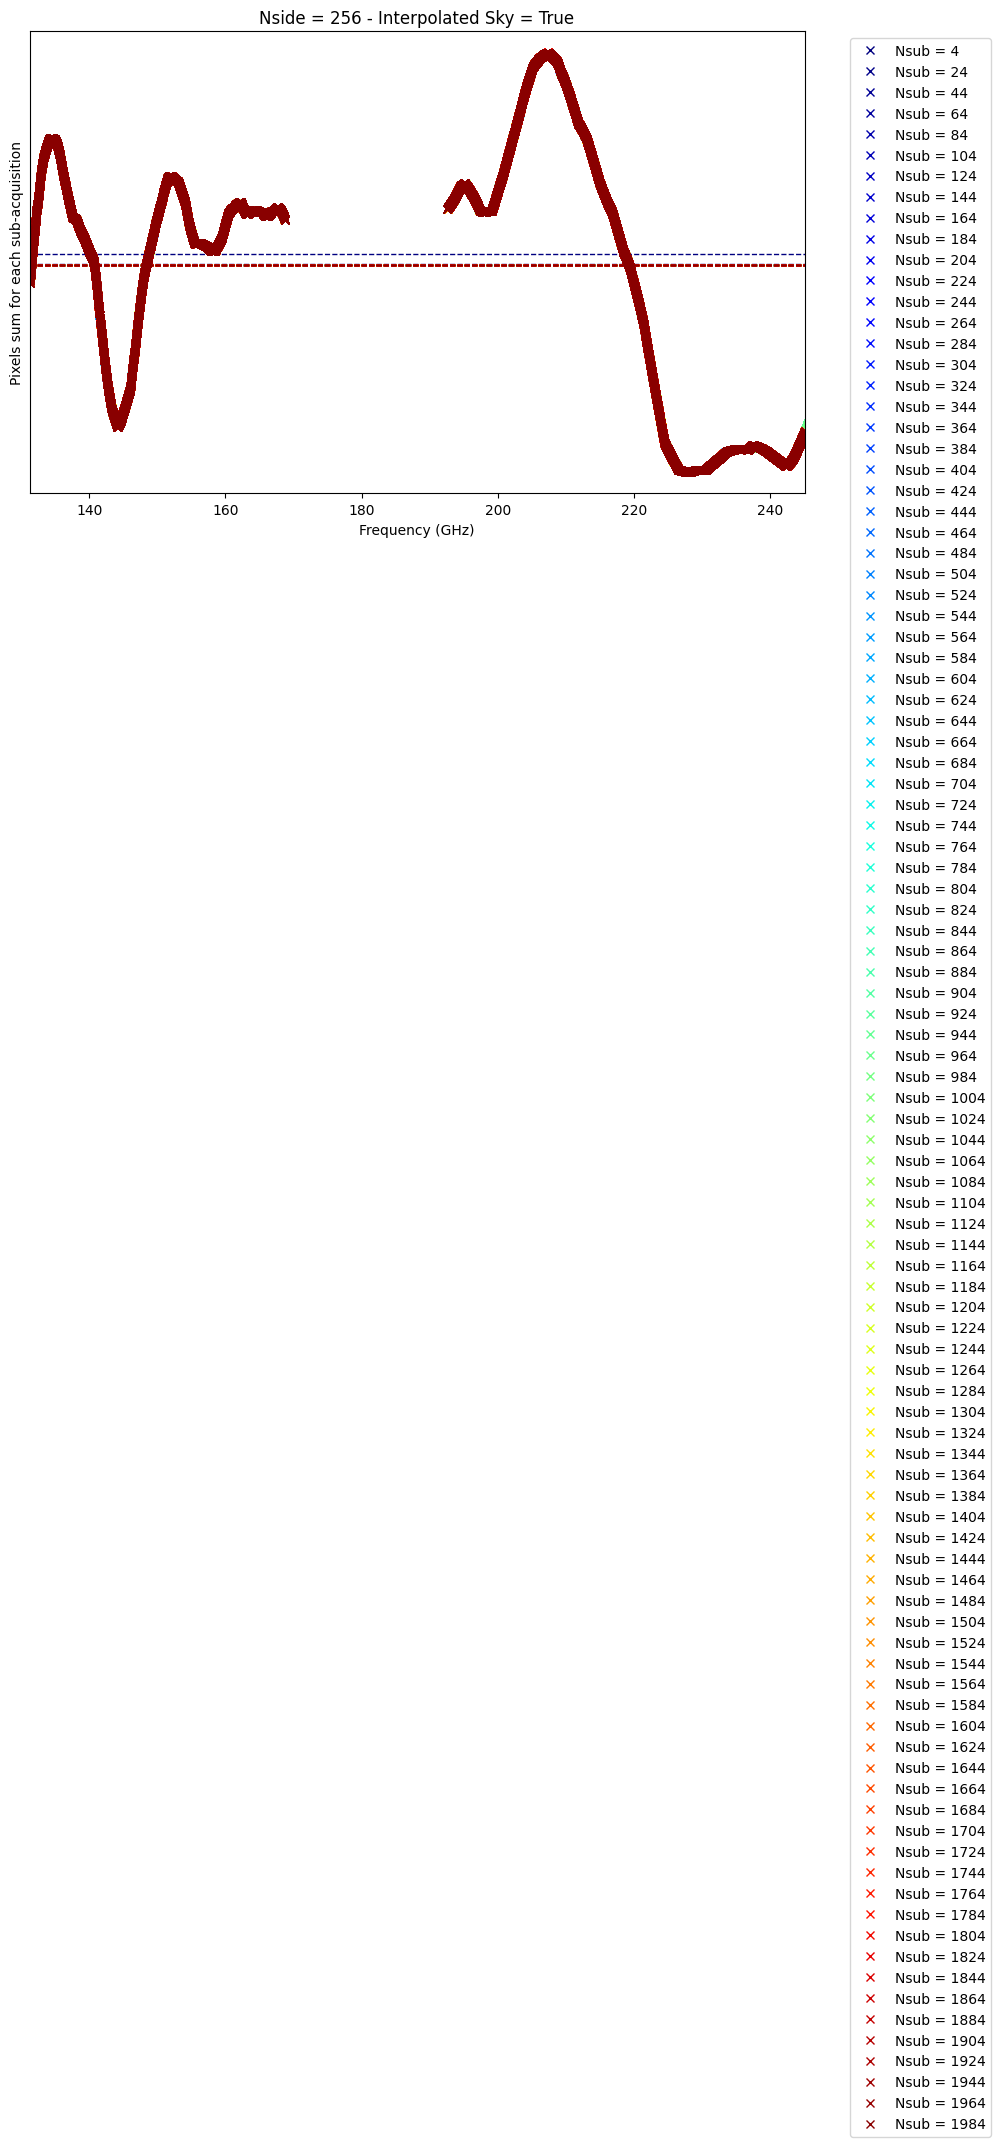

In [40]:
plt.figure(figsize=(10, 6))

idet = 0
ireal = 0

for isub in range(len(nsub_list)):
    color = plt.cm.jet(isub/len(nsub_list))
    plt.plot(freq_list[isub], nreal_tod_w_interp[ireal][isub][:, idet], 'x', color=color, label=f"Nsub = {nsub_list[isub]}")
    plt.hlines(np.mean(nreal_tod_w_interp[ireal][isub][:, idet]), xmin=131.25, xmax=245, color=color, linestyle='--', linewidth=1)
    
plt.title(f"Nside = {nside} - Interpolated Sky = True")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Pixels sum for each sub-acquisition")
plt.yticks([])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(131.25, 245)

(131.25, 245.0)

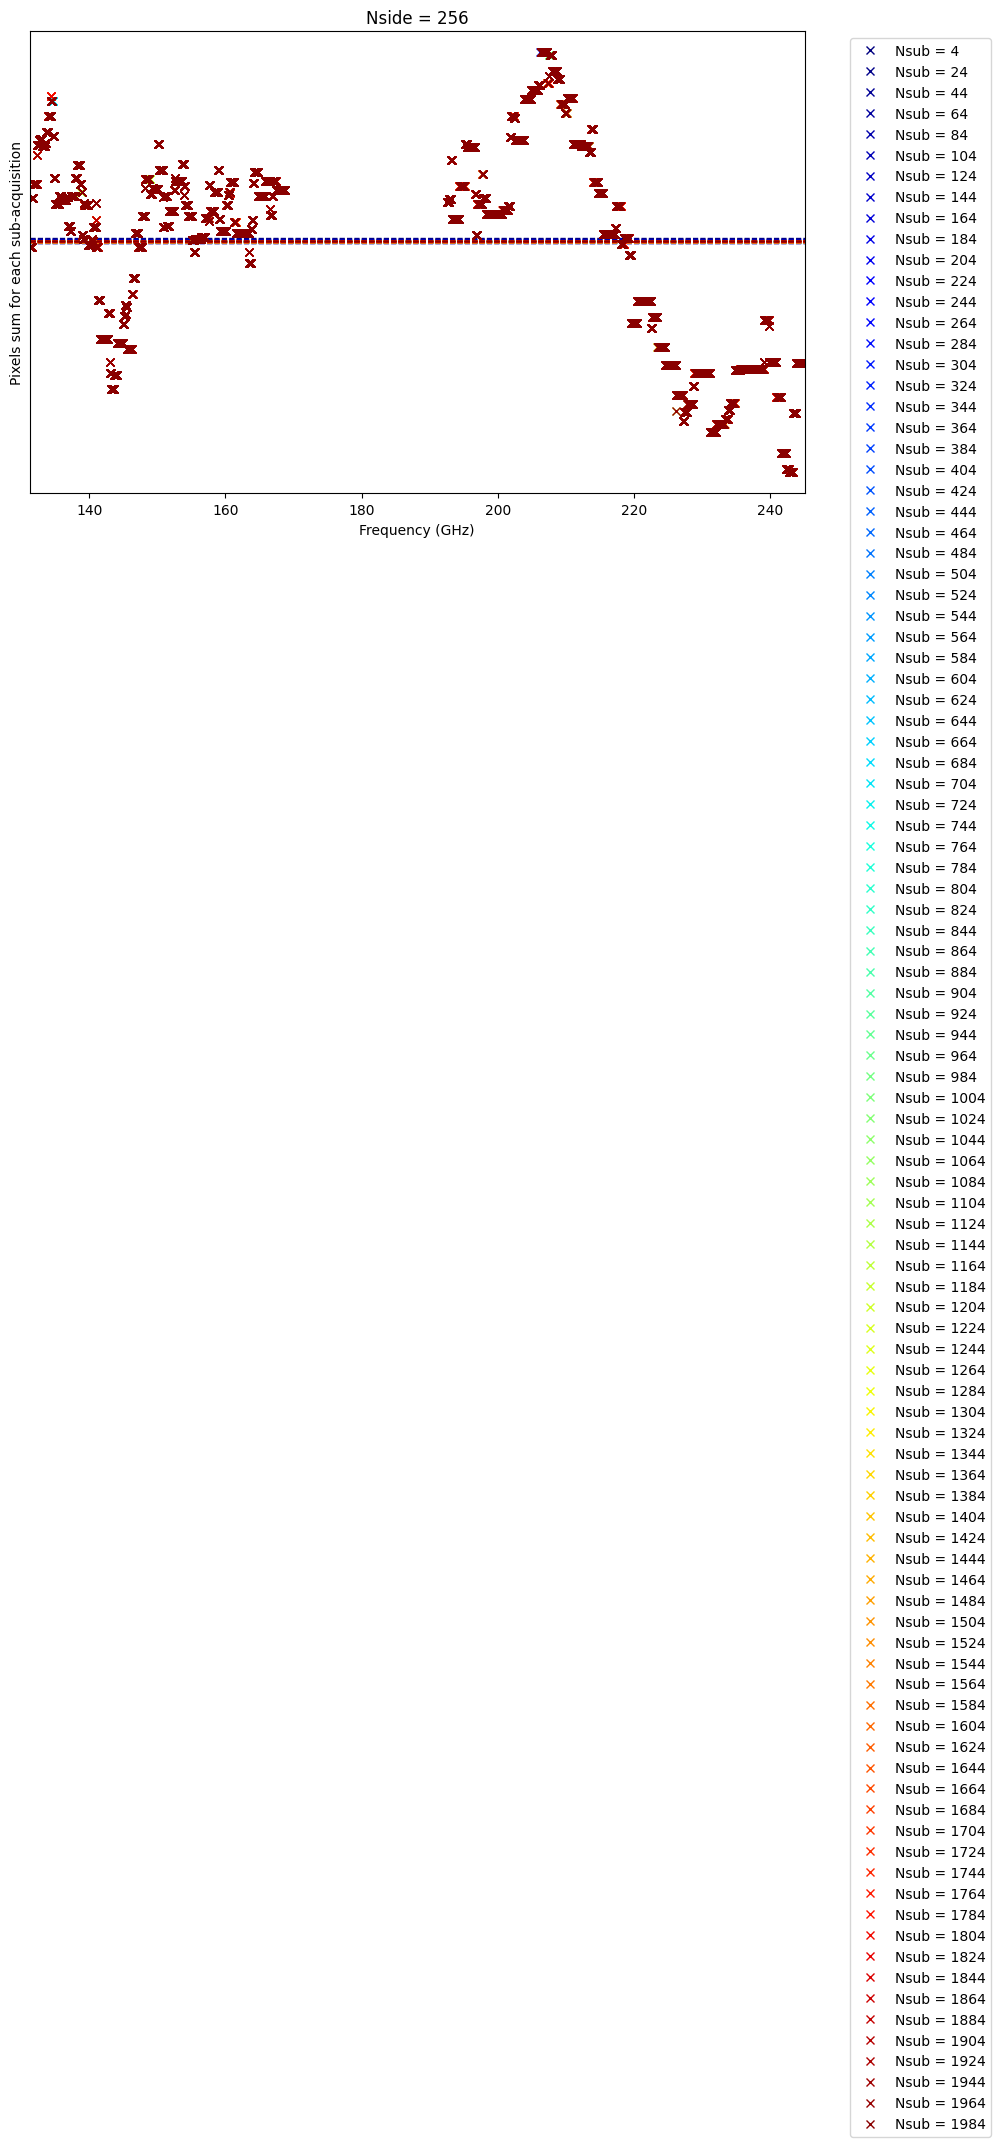

In [41]:
plt.figure(figsize=(10, 6))

idet = 0
ireal = 0

for isub in range(len(nsub_list)):
    color = plt.cm.jet(isub/len(nsub_list))
    plt.plot(freq_list[isub], nreal_tod_wo_interp[ireal][isub][:, idet], 'x', color=color, label=f"Nsub = {nsub_list[isub]}")
    plt.hlines(np.mean(nreal_tod_wo_interp[ireal][isub][:, idet]), xmin=131.25, xmax=245, color=color, linestyle='--', linewidth=1)
    
plt.title(f"Nside = {nside}")# - Detector index = {idet} - Interpolated Sky = False")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Pixels sum for each sub-acquisition")
plt.yticks([])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(131.25, 245)

In [42]:
# Shape 
print(len(tod_list_wo_interp))
print(len(nreal_tod_wo_interp[ireal]))
print(np.shape(nreal_tod_wo_interp[ireal][-1]))

100
100
(1984, 992)


Be careful, when I sum over the sub-tods, I have to multiply by the bandwidth of the sub-bands

In [43]:
rel_diff_w_list = []
rel_diff_wo_list = []

for ireal in range(nreal):
    rel_diff_w, rel_diff_wo = [], []
    for insub in range(len(nsub_list)):
        rel_diff_w.append((np.sum(nreal_tod_w_interp_real[ireal][insub][:, idet], axis=0) - np.sum(nreal_tod_w_interp_real[ireal][-1][:, idet], axis=0)) / np.sum(nreal_tod_w_interp_real[ireal][-1][:, idet], axis=0))
        rel_diff_wo.append((np.sum(nreal_tod_wo_interp_real[ireal][insub][:, idet], axis=0) - np.sum(nreal_tod_wo_interp_real[ireal][-1][:, idet], axis=0)) / np.sum(nreal_tod_wo_interp_real[ireal][-1][:, idet], axis=0))        
    rel_diff_w_list.append(rel_diff_w)
    rel_diff_wo_list.append(rel_diff_wo)

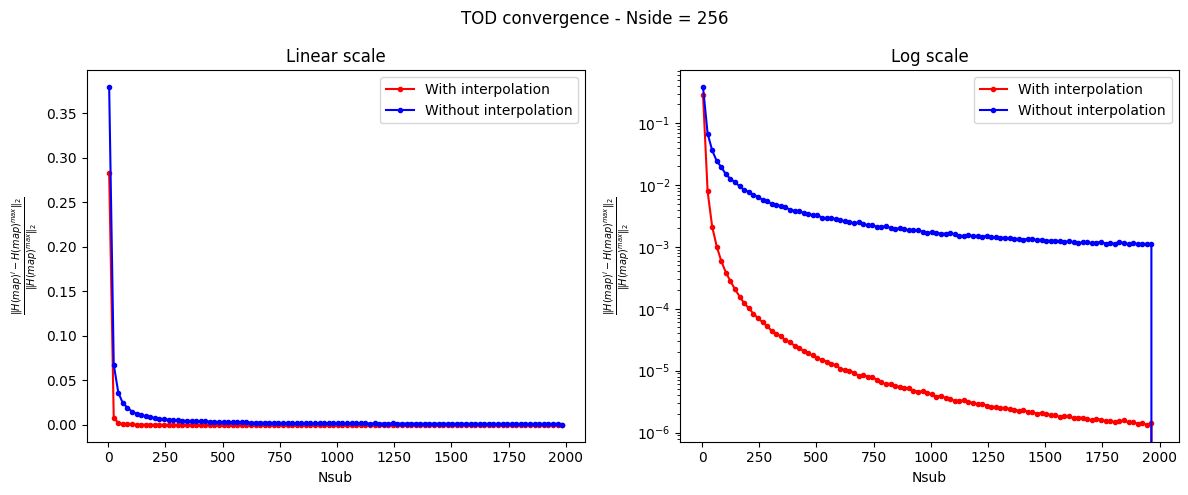

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

norm_rel_w_list = []
norm_rel_wo_list = []

for ireal in range(nreal):
    # Band-integrated TOD per detector (sum over sub-bands only, bandwidth already
    # applied in cell 11) -- keep the per-detector vector, don't sum across
    # detectors: they are different physical channels, summing/norming their raw
    # values would not be physically meaningful. The norm below is taken of the
    # *difference* between two estimates of the same per-detector vector, which
    # is a standard (purely numerical) way to combine many independent per-detector
    # convergence errors into one summary number.
    TOD_band_w = [
        np.sum(nreal_tod_w_interp_real[ireal][insub], axis=0)
        for insub in range(len(nsub_list))
    ]
    TOD_band_wo = [
        np.sum(nreal_tod_wo_interp_real[ireal][insub], axis=0)
        for insub in range(len(nsub_list))
    ]

    norm_rel_w_list.append([
        np.linalg.norm(TOD_band_w[insub] - TOD_band_w[-1]) / np.linalg.norm(TOD_band_w[-1])
        for insub in range(len(nsub_list))
    ])
    norm_rel_wo_list.append([
        np.linalg.norm(TOD_band_wo[insub] - TOD_band_wo[-1]) / np.linalg.norm(TOD_band_wo[-1])
        for insub in range(len(nsub_list))
    ])

mean_norm_rel_w = np.mean(norm_rel_w_list, axis=0)
mean_norm_rel_wo = np.mean(norm_rel_wo_list, axis=0)

for ax in (ax1, ax2):
    ax.plot(nsub_list, np.abs(mean_norm_rel_w), '.-r', label='With interpolation')
    ax.plot(nsub_list, np.abs(mean_norm_rel_wo), '.-b', label='Without interpolation')
    ax.set_xlabel('Nsub')
    ax.set_ylabel(r'$\frac{\|H(map)^{i} - H(map)^{max}\|_2}{\|H(map)^{max}\|_2}$')
    ax.legend()

ax1.set_title("Linear scale")
ax2.set_title("Log scale")
ax2.set_yscale('log')
fig.suptitle(f"TOD convergence - Nside = {nside}")# - Average over {nreal} realisations - Convolutions {convolve_beam}")
plt.tight_layout()
plt.show()

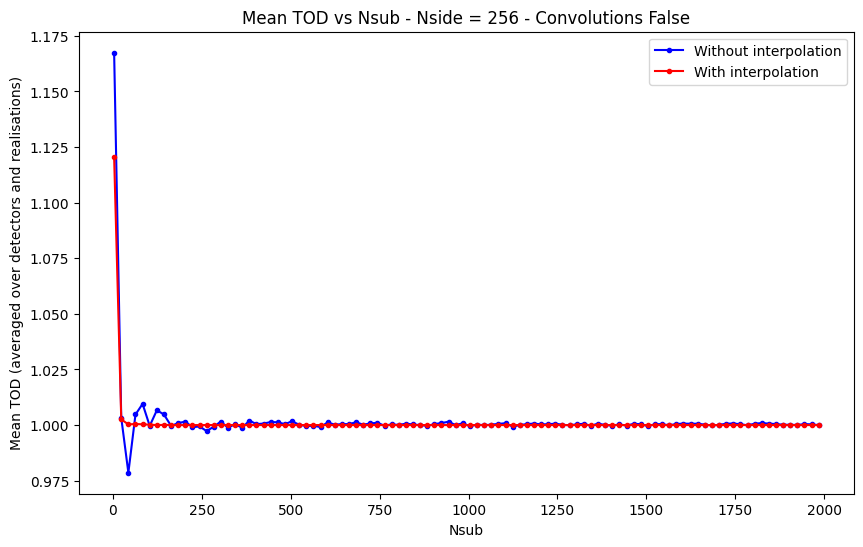

In [45]:
mean_tod_wo = []
mean_tod_w = []

for ireal in range(nreal):
    normalise = np.mean(np.sum(nreal_tod_wo_interp_real[ireal][-1], axis=0))
    normalise_w = np.mean(np.sum(nreal_tod_w_interp_real[ireal][-1], axis=0))

    mean_tod_wo.append([
        np.mean(np.sum(nreal_tod_wo_interp_real[ireal][insub], axis=0)) / normalise
        for insub in range(len(nsub_list))
    ])

    mean_tod_w.append([
        np.mean(np.sum(nreal_tod_w_interp_real[ireal][insub], axis=0)) / normalise_w
        for insub in range(len(nsub_list))
    ])

mean_mean_tod_wo = np.mean(mean_tod_wo, axis=0)
mean_mean_tod_w = np.mean(mean_tod_w, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(nsub_list, mean_mean_tod_wo, '.-b', label='Without interpolation')
plt.plot(nsub_list, mean_mean_tod_w, '.-r', label='With interpolation')
plt.xlabel('Nsub')
plt.ylabel('Mean TOD (averaged over detectors and realisations)')
plt.title(f"Mean TOD vs Nsub - Nside = {nside} - Convolutions {convolve_beam}")
plt.legend()
plt.show()